In [44]:
import torch
import torch.nn as nn

from tensorflow.keras.datasets import imdb

import re

In [45]:
word_index = imdb.get_word_index()

reverse_word_index = {
    value:key
    for key,value in word_index.items()
}

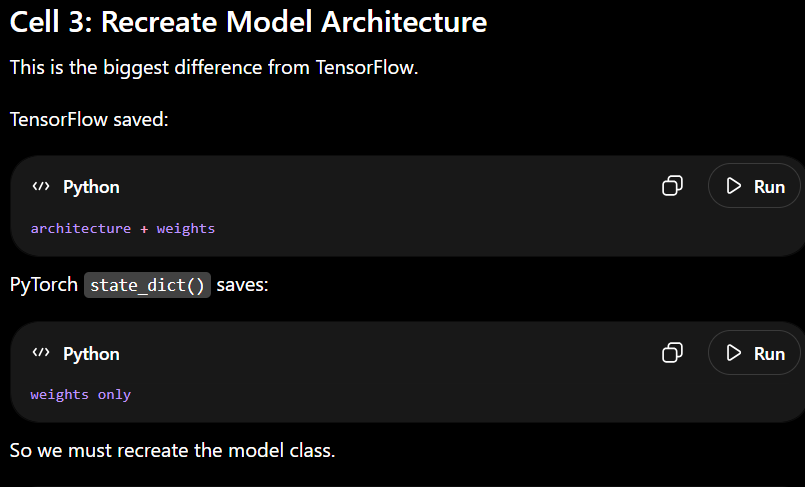

In [46]:
class SimpleRNNClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(
            10000,
            128
        )

        self.rnn = nn.RNN(
            input_size=128,
            hidden_size=128,
            batch_first=True,
            nonlinearity='relu'
        )

        self.fc = nn.Linear(
            128,
            1
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self,x):

        embedded = self.embedding(x)

        output, hidden = self.rnn(
            embedded
        )

        hidden = hidden.squeeze(0)

        output = self.fc(hidden)

        output = self.sigmoid(output)

        return output

In [50]:
model = SimpleRNNClassifier()

model.load_state_dict(
    torch.load(
        "model-files-2/simple_rnn_imdb.pth",
        map_location="cpu"
    )
)

model.eval()

SimpleRNNClassifier(
  (embedding): Embedding(10000, 128)
  (rnn): RNN(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [51]:
MAX_LEN = 500

In [54]:
def preprocess_text(text):

    text = text.lower()

    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        text
    )

    words = text.split()

    encoded_review = []

    for word in words:

        if (
            word in word_index
            and word_index[word] < 10000
        ):

            encoded_review.append(
                word_index[word] + 3
            )

        else:

            encoded_review.append(2)

    encoded_review = encoded_review[-MAX_LEN:]

    if len(encoded_review) < MAX_LEN:

        encoded_review = (
            [0] * (MAX_LEN-len(encoded_review))
            + encoded_review
        )
    review_tensor = torch.tensor(
        [encoded_review],
        dtype=torch.long
    )

    return review_tensor

In [55]:
## prediction function
def predict_sentiment(review):

    review_tensor = preprocess_text(
        review
    )

    with torch.no_grad():

        prediction = model(
            review_tensor
        )

    score = prediction.item()

    sentiment = (
        "Positive"
        if score > 0.5
        else "Negative"
    )

    return sentiment, score

In [56]:
review = (
    "This movie was fantastic! "
    "The acting was great."
)

sentiment, score = predict_sentiment(
    review
)

print(sentiment)
print(score)

Positive
0.8094314932823181
